# [Deepmath] 6.1. Utiliser tensorflow

## Avoid the kernel to plant

In [1]:
import os
# Setting the environment variable OMP_NUM_THREADS or KMP_DUPLICATE_LIB_OK before running code
os.environ['KMP_DUPLICATE_LIB_OK']='True' 
#os.environ['OMP_NUM_THREADS'] = '1' # This didn't work here

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

## Artchitecture du réseau

In [3]:
# Create the model
modele = Sequential()
modele

## Couches de neurones

In [4]:
modele.add(Dense(2, input_dim=1, activation='relu'))

In [5]:
modele.add(Dense(1, activation='relu'))

### Couche 0 : définir à la main les poids

In [6]:
# As input_dim=1 we have one sublist in here
coeff = np.array([[1, -0.5]])
# Biases go in a single list
biais = np.array([-1, 1])
# a list of coeff and biases arrays
poids = [coeff, biais]

Attention !
Si on avait plusieurs entrées, on devrait avoir un 'array' de plusieurs listes de taille n, la ième liste reprenant les coefficients correspondant à la ième variable de notre fonction linéaire.

Par contre, pour les biais, ils sont tous placés dans une seule liste qu'on transforme en 'array'.

In [7]:
modele.layers

In [8]:
modele.layers[0].set_weights(poids)

### Couche 1 : définir à la main les poids

In [9]:
# each sublist correponds to an input variable
# On second layer, the only neuron has two entries thus two sublists
coeff = np.array([[1.], [1.]])
# Biases always go into one list
biais = np.array([0])
poids = [coeff, biais] # a list of arrays

In [10]:
modele.layers[1].set_weights(poids)

### Entrée - Sortie : une seule valeur

In [11]:
entry = np.array([[10.]])
output = modele.predict(entry)
print("x = ", entry, "F(x) = ", output)

1/1 [==============================] - 0s 131ms/step
x =  [[10.]] F(x) =  [[9.]]


### Tracer le graphe de ce réseau des neurones : F(x)

In [12]:
liste_x = np.linspace(-2, 3, num=20)
entries = np.array([ [x] for x in liste_x ])
outputs = modele.predict(entries)
liste_y = np.array([ y[0] for y in outputs])

1/1 [==============================] - 0s 31ms/step


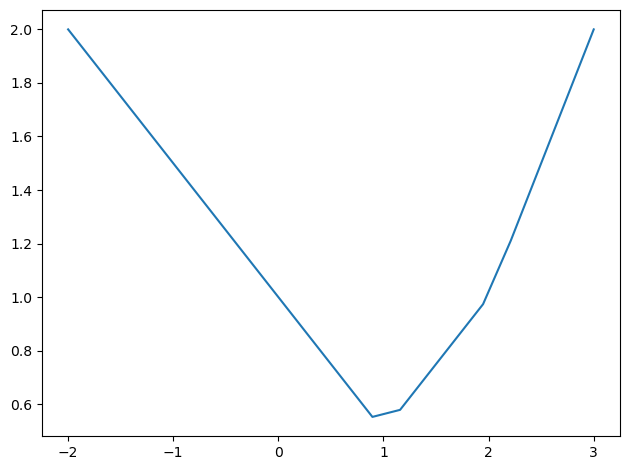

In [15]:
# Il y avait un problème à ce niveau : ce code fait planter le noyau ipython
# Il a été résolu une fois que "  os.environ['KMP_DUPLICATE_LIB_OK']='True' " 
# a été placé au début du code
plt.plot(liste_x, liste_y)
plt.tight_layout()
plt.show()